# Precipitation Distribution

In [1]:
import sys
import os
from pathlib import Path

# Make sure we run relative to the repo root regardless of where Jupyter was launched
ROOT = Path().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

print(f"Working directory: {ROOT}")

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from thesis.config import Config
from thesis.data.registry import DataRegistry

## Parameters

In [3]:
TAU = 0.5  # wet-day threshold (mm)

## Load data

In [5]:
cfg = Config()
registry = DataRegistry.from_config(cfg)
data = registry.stations.load(date_start=cfg.date_start, date_end=cfg.date_end, exclude_holdout=False)

precip = data["precip_mm"].values
months = data["date"].astype("datetime64[ns]").dt.month

print(f"Total station-day records: {len(precip):,}")

Total station-day records: 56,558,580


## Compute dry / trace / wet fractions

In [6]:
is_dry   = precip == 0.0
is_trace = (precip > 0.0) & (precip < TAU)
is_wet   = precip >= TAU

pct_dry   = 100 * is_dry.sum()   / len(precip)
pct_trace = 100 * is_trace.sum() / len(precip)
pct_wet   = 100 * is_wet.sum()   / len(precip)

print(f"Dry   (= 0 mm):  {pct_dry:.1f}%")
print(f"Trace (< τ):     {pct_trace:.1f}%")
print(f"Wet   (≥ τ):     {pct_wet:.1f}%")

Dry   (= 0 mm):  51.9%
Trace (< τ):     9.7%
Wet   (≥ τ):     38.4%


## Plot

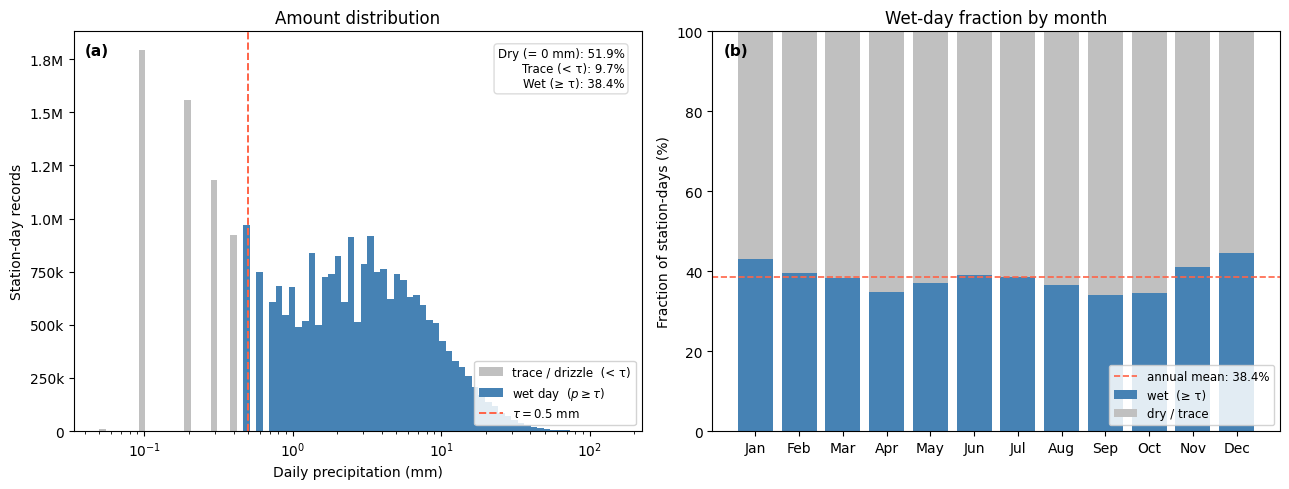

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel (a): Amount distribution (log x-axis) ─────────────────────────────
ax = axes[0]
ax.text(0.02, 0.97, "(a)", transform=ax.transAxes,
        fontsize=11, fontweight="bold", va="top")

bins = np.logspace(np.log10(0.05), np.log10(150), 80)

ax.hist(precip[is_trace], bins=bins, color="silver",
        label=f"trace / drizzle  (< τ)", zorder=2)
ax.hist(precip[is_wet],   bins=bins, color="steelblue",
        label=f"wet day  ($p \\geq \\tau$)", zorder=2)

ax.axvline(TAU, color="tomato", linestyle="--", linewidth=1.4,
           label=f"$\\tau = {TAU}$ mm")

ax.set_xscale("log")
ax.set_xlabel("Daily precipitation (mm)")
ax.set_ylabel("Station-day records")
ax.set_title("Amount distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k" if x >= 1e3 else str(int(x))
))

# Percentage annotations — upper-right, away from legend
ax.text(0.97, 0.96,
        f"Dry (= 0 mm): {pct_dry:.1f}%\n"
        f"Trace (< τ): {pct_trace:.1f}%\n"
        f"Wet (≥ τ): {pct_wet:.1f}%",
        transform=ax.transAxes, fontsize=8.5,
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="lightgrey"))

# Legend in lower-right (away from bars which are densest on the left)
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.85)

# ── Panel (b): Wet-day fraction by month ────────────────────────────────────
ax2 = axes[1]
ax2.text(0.02, 0.97, "(b)", transform=ax2.transAxes,
         fontsize=11, fontweight="bold", va="top")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
wet_frac = []
for m in range(1, 13):
    mask = months == m
    wet_frac.append(100 * (precip[mask] >= TAU).mean())

x = np.arange(1, 13)
dry_frac = [100 - w for w in wet_frac]

ax2.bar(x, wet_frac,  color="steelblue", label=f"wet  (≥ τ)")
ax2.bar(x, dry_frac, bottom=wet_frac, color="silver",  label="dry / trace")

annual_mean_wet = 100 * is_wet.sum() / len(precip)
ax2.axhline(annual_mean_wet, color="tomato", linestyle="--", linewidth=1.2,
            label=f"annual mean: {annual_mean_wet:.1f}%")

ax2.set_xticks(x)
ax2.set_xticklabels(month_names)
ax2.set_ylabel("Fraction of station-days (%)")
ax2.set_ylim(0, 100)
ax2.set_title("Wet-day fraction by month")
ax2.legend(loc="lower right", fontsize=8.5, framealpha=0.85)

fig.tight_layout()
plt.show()